## LSTM for text generation based on Pushkin's texts

In [13]:
with open('pushkin.txt') as f:
    text_database = f.read()

CYRILLIC_SYMBOLS = set('абвгдеёжзийклмнопрстуфхцчшщъыьэюяєіїґ')
PUNCTUATION_SYMBOLS = set('!"#$%&\'()*+,-./:;<=>?@[\\]_`{|}~«»… \t\n')

def normalize_text(text):
    """Replace various dash characters with regular hyphen"""
    # Replace all types of dashes with regular hyphen
    dashes = ['–', '—', '−', '‒', '―', '‐', '‑']
    for dash in dashes:
        text = text.replace(dash, '-')
    return text.replace('\xa0', ' ').strip()

all_lines = text_database.split('\n')
verse_lines = [
    normalize_text(line)
    for line in all_lines 
    # All verses are starting with two tabs in this text corpus
    if line.startswith('\t\t')
]

training_lines = [
    line.lower()
    for line in verse_lines 
    # Remove verses that contain non-cyrillic symbols and non-punctuation symbols
    if all(char.lower() in CYRILLIC_SYMBOLS or char in PUNCTUATION_SYMBOLS for char in line)
        # Some verses are empty or really small, let's get rid of them
        and len(line) >= 5
]
training_data = "\n".join(training_lines)

character_set = sorted(list(set(training_data)))
vocabulary_size = len(character_set)
print("Character set:", f"{vocabulary_size} chars", "".join(character_set))

verse_lengths = [len(verse) for verse in training_lines]
print(f"Average length: {sum(verse_lengths) / len(verse_lengths):.1f} chars")
print(f"Min length: {min(verse_lengths)}")
print(f"Max length: {max(verse_lengths)}")
print(f"Median length: {sorted(verse_lengths)[len(verse_lengths)//2]}")
print("Total lines:", len(training_lines))

print("\nSample text:\n" + training_data[:100])

Character set: 54 chars 
 !"'()*,-.:;<>?[]«»абвгдежзийклмнопрстуфхцчшщъыьэюяё…
Average length: 27.4 chars
Min length: 5
Max length: 58
Median length: 26
Total lines: 20712

Sample text:
скажите мне, почему «похититель»
освистан партером?
увы, потому что бедный автор
похитил его у молье


In [14]:
char_to_index = {u:i for i, u in enumerate(character_set)}
index_to_char = {i:u for i, u in enumerate(character_set)}

print(char_to_index)
print(index_to_char)

{'\n': 0, ' ': 1, '!': 2, '"': 3, "'": 4, '(': 5, ')': 6, '*': 7, ',': 8, '-': 9, '.': 10, ':': 11, ';': 12, '<': 13, '>': 14, '?': 15, '[': 16, ']': 17, '«': 18, '»': 19, 'а': 20, 'б': 21, 'в': 22, 'г': 23, 'д': 24, 'е': 25, 'ж': 26, 'з': 27, 'и': 28, 'й': 29, 'к': 30, 'л': 31, 'м': 32, 'н': 33, 'о': 34, 'п': 35, 'р': 36, 'с': 37, 'т': 38, 'у': 39, 'ф': 40, 'х': 41, 'ц': 42, 'ч': 43, 'ш': 44, 'щ': 45, 'ъ': 46, 'ы': 47, 'ь': 48, 'э': 49, 'ю': 50, 'я': 51, 'ё': 52, '…': 53}
{0: '\n', 1: ' ', 2: '!', 3: '"', 4: "'", 5: '(', 6: ')', 7: '*', 8: ',', 9: '-', 10: '.', 11: ':', 12: ';', 13: '<', 14: '>', 15: '?', 16: '[', 17: ']', 18: '«', 19: '»', 20: 'а', 21: 'б', 22: 'в', 23: 'г', 24: 'д', 25: 'е', 26: 'ж', 27: 'з', 28: 'и', 29: 'й', 30: 'к', 31: 'л', 32: 'м', 33: 'н', 34: 'о', 35: 'п', 36: 'р', 37: 'с', 38: 'т', 39: 'у', 40: 'ф', 41: 'х', 42: 'ц', 43: 'ч', 44: 'ш', 45: 'щ', 46: 'ъ', 47: 'ы', 48: 'ь', 49: 'э', 50: 'ю', 51: 'я', 52: 'ё', 53: '…'}


#### LSTM layer with manual calculations and logits output

In [15]:
import torch
import torch.nn as nn

class LstmLayer(nn.Module):
    def __init__(self, input_size, output_size, num_classes):
        super().__init__()
        self.input_size = input_size
        self.output_size = output_size
        self.num_classes = num_classes
        self.stacked_size = input_size + output_size
        
        # Smaller initial gradients for better stability
        self.Wc = nn.Parameter(torch.randn(self.stacked_size, self.output_size) * 0.01)
        self.bc = nn.Parameter(torch.zeros(self.output_size))

        self.Wu = nn.Parameter(torch.randn(self.stacked_size, self.output_size) * 0.01)
        self.bu = nn.Parameter(torch.zeros(self.output_size))

        self.Wf = nn.Parameter(torch.randn(self.stacked_size, self.output_size) * 0.01)
        self.bf = nn.Parameter(torch.zeros(self.output_size))

        self.Wo = nn.Parameter(torch.randn(self.stacked_size, self.output_size) * 0.01)
        self.bo = nn.Parameter(torch.zeros(self.output_size))

        # Fully connected layer for softmax output
        self.Wy = nn.Parameter(torch.randn(self.output_size, self.num_classes) * 0.01)
        self.by = nn.Parameter(torch.zeros(self.num_classes))
        
    def forward(self, x, a_prev, c_prev):
        stacked = torch.cat([a_prev, x], dim=1)
        c_hat = torch.tanh(stacked @ self.Wc + self.bc)
        Gu = torch.sigmoid(stacked @ self.Wu + self.bu)
        Gf = torch.sigmoid(stacked @ self.Wf + self.bf)
        Go = torch.sigmoid(stacked @ self.Wo + self.bo)
        c = Gu * c_hat + Gf * c_prev
        a = Go * torch.tanh(c)
        y_logits = a @ self.Wy + self.by
        return a, c, y_logits

In [ ]:
import torch
import torch.nn.functional as F

def prepare_sequence_batch(sequences, char_to_index, vocab_size):
    """
    Convert list of sequences into list of one-hot tensors per time step.
    
    Args:
        sequences: List of strings, e.g., ["first verse", "second vers"]
        char_to_index: Dict mapping char → index
        vocab_size: Size of vocabulary
    
    Returns:
        List of (batch_size, vocab_size) tensors, one per time step
    """
    # Convert sequences to indices
    # Shape: (batch_size, seq_len)
    seq_len = len(sequences[0])
    batch_size = len(sequences)
    
    indices = torch.zeros(batch_size, seq_len, dtype=torch.long)
    for i, seq in enumerate(sequences):
        for t, char in enumerate(seq):
            indices[i, t] = char_to_index[char]

    # Convert to one-hot and transpose to list of time steps
    # one_hot: (batch_size, seq_len, vocab_size)
    one_hot = F.one_hot(indices, num_classes=vocab_size).float()
    
    # Split by time step: list of (batch_size, vocab_size)
    time_steps = [one_hot[:, t, :] for t in range(seq_len)]
    
    return time_steps

# Example usage
sequences = ["амбразура !", "балагура !!"]

vocab_size = 54
time_steps = prepare_sequence_batch(sequences, char_to_index, vocab_size)

print(f"Number of time steps: {len(time_steps)}")  # 11
print(f"Each time step shape: {time_steps[0].shape}")  # (2, 54)
print(f"First time step (chars 'а' and 'б'):\n{time_steps[0]}")

Number of time steps: 11
Each time step shape: torch.Size([2, 54])
First time step (chars 'а' and 'б'):
tensor([[0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]])


#### Inference with sampling for a few examples in a batch

In [30]:
def run_inference_with_sampling(
    layer, 
    vocabulary_size, 
    hidden_size, 
    num_samples, 
    num_lines,
):
    # Run inference for num_samples samples, up to num_lines verse lines
    with torch.no_grad():
        for i in range(num_samples):
            # Start with newline so that we start from a new line verse
            sample_verse = "\n"
            num_generated_lines = 0
            num_generated_characters = 0

            # Current batch size is 1
            a_prev = torch.zeros(1, hidden_size)
            c_prev = torch.zeros(1, hidden_size)
            while num_generated_lines < num_lines and num_generated_characters < 200:  # Some limit
                last_generated_character = sample_verse[-1]
                # tensor for the last character
                x_current = prepare_sequence_batch([last_generated_character], char_to_index, vocabulary_size)[0]
                a_current, c_current, y_logits = layer(x=x_current, a_prev=a_prev, c_prev=c_prev)
                a_prev = a_current
                c_prev = c_current
                y_probs = torch.softmax(y_logits, dim=1)
                sampled_idx = torch.multinomial(y_probs, num_samples=1)
                new_character = index_to_char[sampled_idx.item()]
                sample_verse += new_character
                num_generated_characters += 1
                if new_character == "\n":
                    num_generated_lines += 1
            print("***")
            print(sample_verse)


#### Manual training code with hand-coded cross-entropy loss

In [ ]:
class LstmTrainer:
    def __init__(
        self, 
        training_data,
        vocabulary_size,
        hidden_size,
        temporal_depth,
    ) -> None:
        self.training_data = training_data
        self.vocabulary_size = vocabulary_size
        self.hidden_size = hidden_size
        self.temporal_depth = temporal_depth

    def train_manual_lstm(self, num_epochs, batch_size, learning_rate):
        # Each training example is a sequence of length self.temporal_depth
        num_training_exampes = len(self.training_data) - self.temporal_depth
        X = [self.training_data[m:m+self.temporal_depth] for m in range(num_training_exampes)]

        # True value for the next predicted characters is Y, same as X shifted by 1 to the left
        shifted_training_data = self.training_data[1:] + "\n"
        Y = [shifted_training_data[m:m+self.temporal_depth] for m in range(num_training_exampes)]

        # Input size is vocabulary size because each character is one-hot encoded
        # output_size is the hidden layer activation/memory size, we can experiment with it
        layer = LstmLayer(input_size=self.vocabulary_size, output_size=self.hidden_size, num_classes=self.vocabulary_size) 

        losses = []
        epoch_losses = []
        for epoch in range(num_epochs):
            epoch_loss = 0
            num_batches = 0
            for batch_start in range(0, num_training_exampes, batch_size):
                current_batch_size = min(batch_size, num_training_exampes - batch_start)
                X_batch = X[batch_start:batch_start+current_batch_size]
                Y_batch = Y[batch_start:batch_start+current_batch_size]

                X_batch_onehot = prepare_sequence_batch(X_batch, char_to_index, self.vocabulary_size)
                Y_batch_onehot = prepare_sequence_batch(Y_batch, char_to_index, self.vocabulary_size)

                a_prev = torch.zeros(current_batch_size, self.hidden_size)
                c_prev = torch.zeros(current_batch_size, self.hidden_size)
                
                total_loss = 0
                for t in range(self.temporal_depth):
                    x_current = X_batch_onehot[t]
                    y_current = Y_batch_onehot[t]

                    # 1. FORWARD PASS
                    a_current, c_current, y_logits = layer(x=x_current, a_prev=a_prev, c_prev=c_prev)
                    a_prev = a_current
                    c_prev = c_current

                    # 2. Loss
                    # pick true logits for cross entropy loss
                    true_logits = torch.sum(y_logits * y_current, dim=1, keepdim=True)

                    # log-sum-exp trick
                    logits_max = torch.max(y_logits, dim=1, keepdim=True)[0]
                    # remainder of log-sum-exp:
                    logits_remainder = torch.log(
                        torch.sum(torch.exp(y_logits - logits_max), dim=1, keepdim=True)
                    )

                    # Sum for all training examples to the final scalar value for this batch
                    total_loss += torch.sum(-true_logits + logits_max + logits_remainder)

                # Average total loss based on batch size and number of temporal steps
                total_loss = total_loss / (current_batch_size * self.temporal_depth)
                # Autograd to calculate all gradients automatically
                total_loss.backward()
                # Apply basic gradient descent with learning rate
                with torch.no_grad():
                    layer.Wc -= learning_rate * layer.Wc.grad
                    layer.bc -= learning_rate * layer.bc.grad
                    layer.Wc.grad.zero_()
                    layer.bc.grad.zero_()

                    layer.Wu -= learning_rate * layer.Wu.grad
                    layer.bu -= learning_rate * layer.bu.grad
                    layer.Wu.grad.zero_()
                    layer.bu.grad.zero_()

                    layer.Wf -= learning_rate * layer.Wf.grad
                    layer.bf -= learning_rate * layer.bf.grad
                    layer.Wf.grad.zero_()
                    layer.bf.grad.zero_()

                    layer.Wo -= learning_rate * layer.Wo.grad
                    layer.bo -= learning_rate * layer.bo.grad
                    layer.Wo.grad.zero_()
                    layer.bo.grad.zero_()

                    layer.Wy -= learning_rate * layer.Wy.grad
                    layer.by -= learning_rate * layer.by.grad
                    layer.Wy.grad.zero_()
                    layer.by.grad.zero_()

                # Just for tracking
                losses.append(total_loss.item())
                epoch_loss += total_loss.item()
                num_batches += 1
            
            # Print average loss for this epoch
            avg_epoch_loss = epoch_loss / num_batches
            epoch_losses.append(avg_epoch_loss)
            if epoch % 10 == 0:
                print(f"Epoch {epoch+1}/{num_epochs}, Average Loss: {avg_epoch_loss:.4f}")
                # Print some text examples to show how they are changing with training time
                run_inference_with_sampling(
                    layer, 
                    self.vocabulary_size,
                    hidden_size=self.hidden_size,
                    num_samples=1, 
                    num_lines=4,
                )                
        return layer, losses


Epoch 1/100, Average Loss: 488.1631
Epoch 2/100, Average Loss: 460.1717
Epoch 3/100, Average Loss: 452.7923
Epoch 4/100, Average Loss: 448.8514
Epoch 5/100, Average Loss: 446.3063
Epoch 6/100, Average Loss: 444.4528
Epoch 7/100, Average Loss: 443.0171
Epoch 8/100, Average Loss: 441.8616
Epoch 9/100, Average Loss: 440.9060
Epoch 10/100, Average Loss: 440.0987
Epoch 11/100, Average Loss: 439.4043
Epoch 12/100, Average Loss: 438.7968
Epoch 13/100, Average Loss: 438.2581
Epoch 14/100, Average Loss: 437.7753
Epoch 15/100, Average Loss: 437.3391
Epoch 16/100, Average Loss: 436.9427
Epoch 17/100, Average Loss: 436.5808
Epoch 18/100, Average Loss: 436.2490
Epoch 19/100, Average Loss: 435.9438
Epoch 20/100, Average Loss: 435.6618
Epoch 21/100, Average Loss: 435.4005
Epoch 22/100, Average Loss: 435.1573
Epoch 23/100, Average Loss: 434.9303
Epoch 24/100, Average Loss: 434.7175
Epoch 25/100, Average Loss: 434.5174
Epoch 26/100, Average Loss: 434.3287
Epoch 27/100, Average Loss: 434.1500
Epoch 28/1

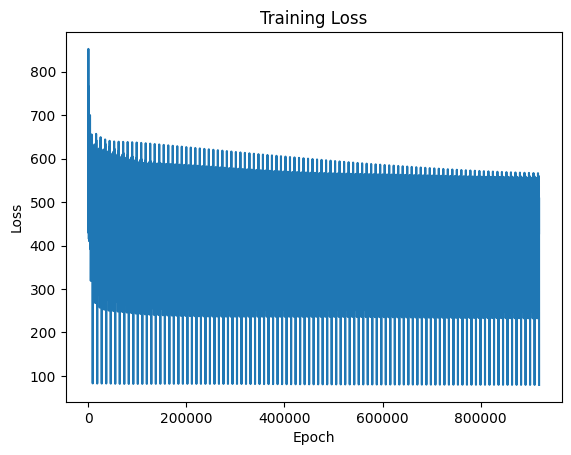

In [ ]:
import matplotlib.pyplot as plt

trainer = LstmTrainer(
    training_data=training_data,
    vocabulary_size=vocabulary_size,
    hidden_size=128,
    temporal_depth=3,
)
layer, losses = trainer.train_manual_lstm(
    num_epochs=100,
    batch_size=64,
    learning_rate=0.01,
)

# Plot loss curve
plt.plot(losses)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss')
plt.show()

In [ ]:
run_inference_with_sampling(
    layer, 
    vocabulary_size, 
    hidden_size=128,
    num_samples=1, 
    num_lines=4,
)

***

по то болик рона.] араве - шиссящ [жел. учесвертой храшей пибне вечугоя бодвазеверем
ребря, что ваглак с душнет и бог, -
такли, о жуизчкощ-усь!.?н,
чь! желонасень иеве ский, с уедия?»

